In [15]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


rfm_df = pd.read_csv('rfm_data.csv')

In [3]:
rfm_df.head()

,CUSTOMER_ID,TOTAL_INVOICED,TOTAL_PAID,ARR_QUARTILE,AR_PAID_RATIO,AR_PAID_RATIO_QUARTILE,AR_STANDARD_SERVICES,AR_RESERVICE_SERVICES,AR_SERVICE_TYPE_RATIO,AR_SERVICE_TYPE_RATIO_QUARTILE,ANNUAL_RECURRING_SERVICES,CUST_AGE_MONTHS
0,2654135,158.0,307.0,1,1.943038,4,1.0,6.0,0.166667,1,8,36
1,2159710,285.0,285.0,1,1.000000,4,3.0,15.0,0.200000,1,4,49
2,2580875,536.0,134.0,1,0.250000,1,1.0,4.0,0.250000,1,4,37
3,3185909,129.0,129.0,1,1.000000,4,1.0,4.0,0.250000,1,4,14
4,3162497,134.0,124.0,1,0.925373,3,1.0,4.0,0.250000,1,8,15


In [8]:
from mpl_toolkits.mplot3d import Axes3D

def scatter_plot(df, x_col, y_col, z_col, title=None, xlabel=None, ylabel=None, zlabel=None, figsize=(8,6), alpha=0.5):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df[x_col], df[y_col], df[z_col], alpha=alpha)
    ax.set_title(title if title else f"{x_col} vs {y_col} vs {z_col}")
    ax.set_xlabel(xlabel if xlabel else x_col)
    ax.set_ylabel(ylabel if ylabel else y_col)
    ax.set_zlabel(zlabel if zlabel else z_col)
    plt.show()

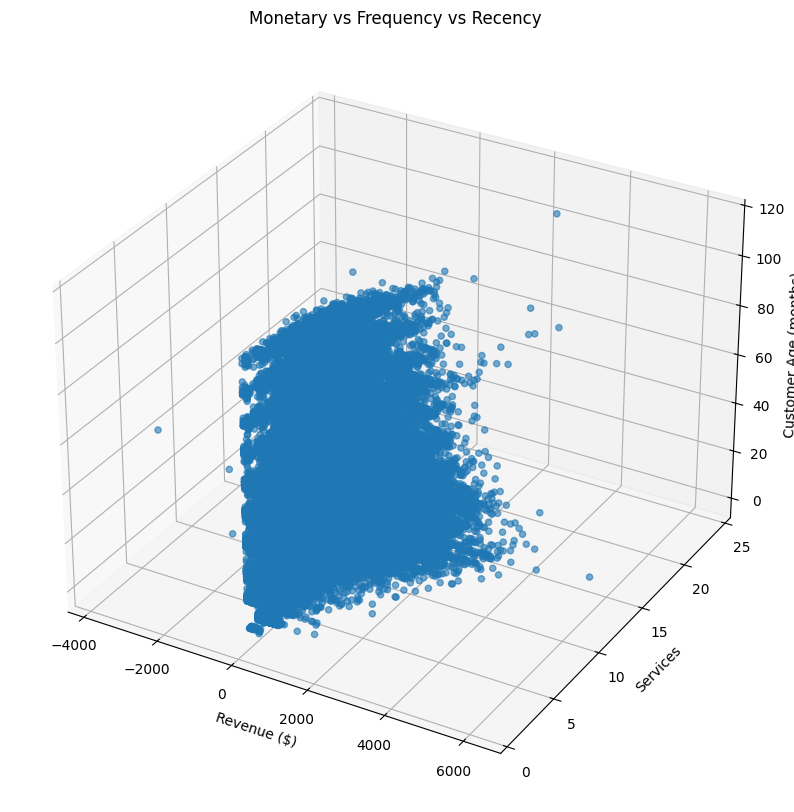

In [14]:
scatter_plot(rfm_df, 'TOTAL_PAID', 'AR_STANDARD_SERVICES', 'CUST_AGE_MONTHS', title='Monetary vs Frequency vs Recency', xlabel='Revenue ($)', ylabel='Services', zlabel='Customer Age (months)', figsize=(12, 10), alpha=0.6)

In [24]:
from matplotlib.backends.backend_pdf import PdfPages

# Description of methodology
methodology = """
Customer Segmentation and Value Analysis Methodology

1. Data Cleaning:
    - Removed rows with missing or infinite values for key metrics (revenue, services, customer age).

2. Visualization:
    - Created a 2x2 grid of plots:
      a) 2D histogram (heatmap) of customer count by revenue and services.
      b) 2D heatmap of average customer age in each revenue/services bin.
      c) Scatter plot of individual customers colored by age.
      d) Hexbin plot showing average age by revenue/services.

3. Segmentation:
    - Customers were segmented into quartiles for revenue, services, and age.
    - A composite score was calculated using weighted quartile scores:
      * Revenue: 50%
      * Services: 30%
      * Age: 20%
    - Customers were assigned to value tiers (Bronze, Silver, Gold, Platinum, Diamond) based on composite score quintiles.

4. Summary:
    - Segment statistics (count, mean, median for revenue, services, and age) were calculated for each tier.
"""

# Save to PDF
with PdfPages('customer_value_analysis.pdf') as pdf:
     # Add the 2x2 heatmap figure
     pdf.savefig(fig, bbox_inches='tight')
     
     # Add the segmentation scatter plot
     plt.figure(figsize=(10, 6))
     for tier in df_segmented['customer_tier'].unique():
          tier_data = df_segmented[df_segmented['customer_tier'] == tier]
          plt.scatter(tier_data['TOTAL_PAID'], tier_data['AR_STANDARD_SERVICES'], 
                          c=colors[tier], label=tier, alpha=0.7, s=30)
     plt.xlabel('12-Month Revenue ($)')
     plt.ylabel('12-Month Services Count')
     plt.title('Customer Segmentation by Composite Value Score')
     plt.legend(title='Customer Tier')
     plt.grid(True, alpha=0.3)
     pdf.savefig(bbox_inches='tight')
     plt.close()
     
     # Add the methodology as a text page
     from matplotlib import pyplot as plt
     plt.figure(figsize=(8.5, 11))
     plt.axis('off')
     plt.text(0, 1, methodology, va='top', ha='left', wrap=True, fontsize=12)
     pdf.savefig(bbox_inches='tight')
     plt.close()
     
     # Add the segment summary as a table
     fig_summary, ax_summary = plt.subplots(figsize=(10, 2))
     ax_summary.axis('off')
     tbl = ax_summary.table(cellText=segment_summary.values,
                                    colLabels=[f"{i[0]}\n{i[1]}" for i in segment_summary.columns],
                                    rowLabels=segment_summary.index,
                                    loc='center')
     tbl.auto_set_font_size(False)
     tbl.set_fontsize(10)
     tbl.scale(1.2, 1.2)
     plt.title('Customer Segment Summary', fontsize=14, fontweight='bold')
     pdf.savefig(fig_summary, bbox_inches='tight')
     plt.close(fig_summary)

print("PDF saved as 'customer_value_analysis.pdf'")


PDF saved as 'customer_value_analysis.pdf'
